In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hwk2-task2-salmon.ipynb")

# Task 2: Wrangling Alaska salmon catch data 

## Instructions 

- First, update the following cell to have a link to *your* Homework 2 GitHub repository:

**UPDATE THIS LINK**
https://github.com/Awoo56709/eds220-hwk2


- Review the [complete rubric for this task](https://docs.google.com/document/d/1x0BoU6IH4cnOR1-n7i9CYQ9wUC37yDpYlQ4j6rCfcsU/edit?tab=t.0) before starting.

- **Meaningful commits should be made every time you finish a major step.** We'll check your repository and view the commit history.

- **Every code cell should have a comment.** Err on the side of commenting too much for now. Comments should follow best practices.

- **Do not update the top cell with the `otter` import**, this is used internally for grading.

## Acknowledgments

This exercise is based on the [Cleaning and Wrangling Data in R lesson by the NCEAS Learning Hub](https://learning.nceas.ucsb.edu/2023-06-delta/session_11.html).


> Halina Do-Linh, Carmen Galaz García, Matthew B. Jones, Camila Vargas Poulsen. 2023. Open Science Synthesis training Week 1. NCEAS Learning Hub & Delta Stewardship Council.


## About the data

In this task you will use simplified data from the Alaska Department of Fish & Game containing commercial salmon catch data from 1878 to 1997. The original data can be accessed from the KNB repository:

> [Mike Byerly. (2016). Alaska commercial salmon catches by management region (1886-1997).](https://knb.ecoinformatics.org/view/df35b.304.2) Gulf of Alaska Data Portal. df35b.304.2.

The simplified dataset is in CSV format in the homework repository and has the following columns:

| Column | Description |
| ------ | ----------- | 
| Regions | Region code |
| Year | Year fish were caught |
| notesRegCode | Notes and comments |
| Species | Species of salmon caught |
| Catch | Commercial catches of salmon species (in thousands of fish) |

## COMPLETE WORKFLOW

You will use the next code cell to complete the last exercise in the task. Leave it blank for now. 

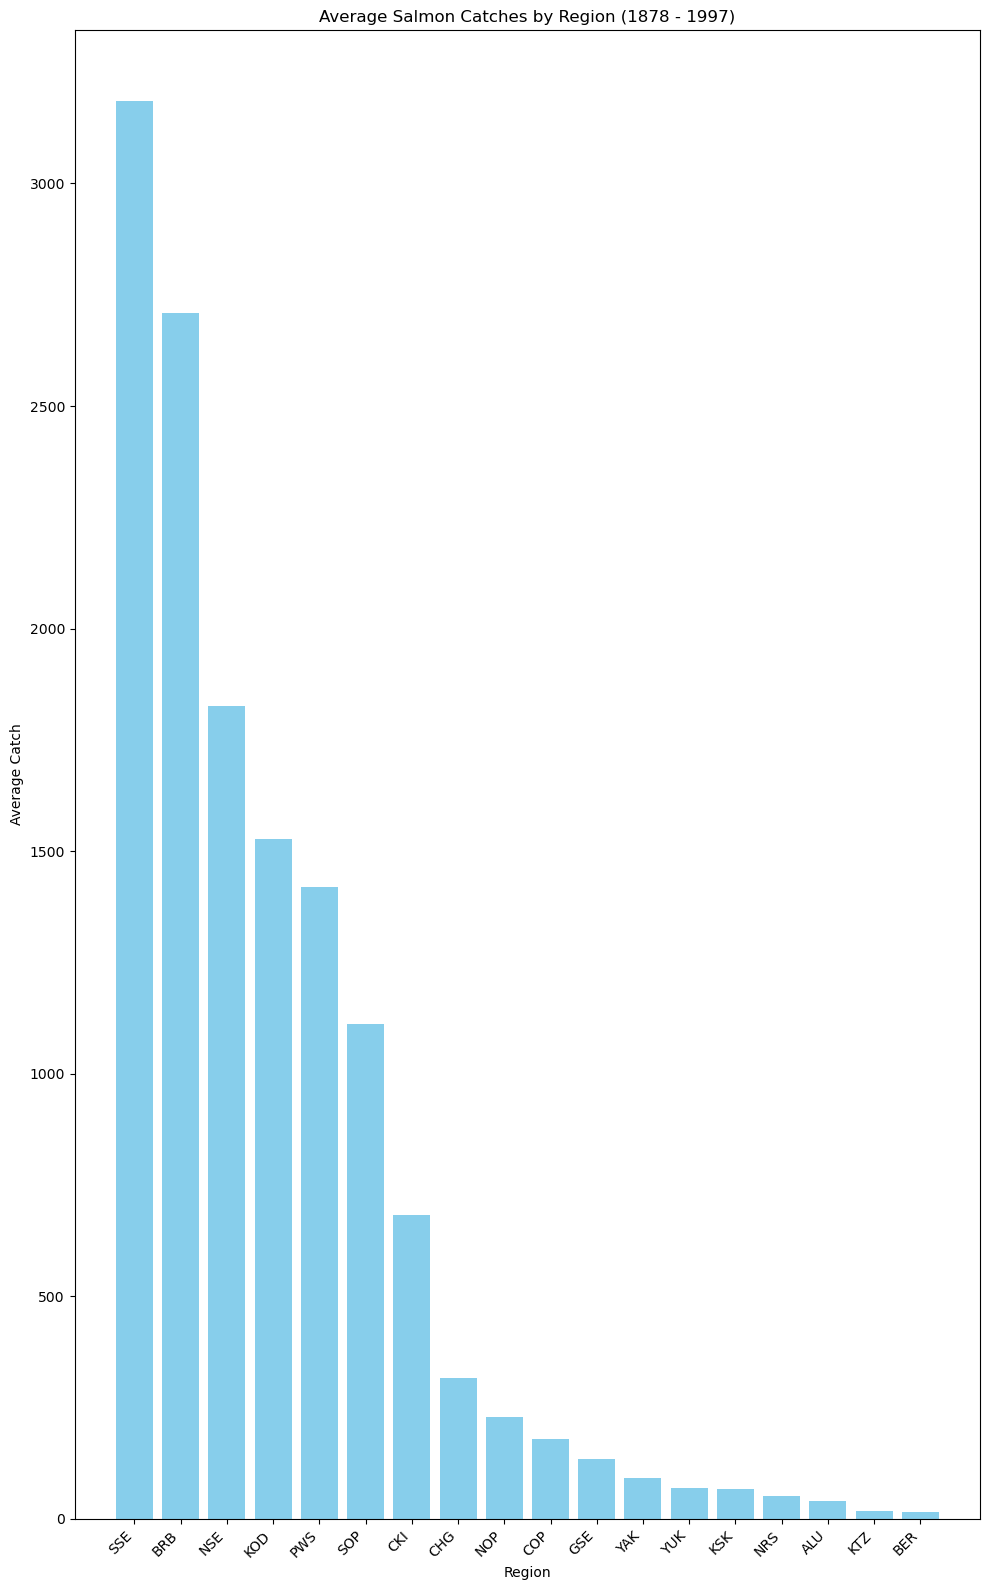

In [56]:
# FINAL CODE

# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# loading in the data
catch_data = pd.read_csv('data/salmon_data.csv')

# changing the value of 'I' to 1
catch_data.loc[400, 'Catch'] = 1  # assignment, not comparison

# converting the "Catch" column to int64 type
catch_data['Catch'] = catch_data['Catch'].astype("int64")

# filtering for specific years
filtered_data = catch_data[(catch_data['Year'] >= 1878) & (catch_data["Year"] <= 1997)]

# grouping by region and calculating an average
avg_region = filtered_data.groupby("Region", as_index=False)["Catch"].mean()

# sorting by magnitude
avg_region_sorted = avg_region.sort_values("Catch", ascending=False)

# plotting
plt.figure(figsize=(10, 16))
plt.bar(avg_region_sorted["Region"], avg_region_sorted["Catch"], color="skyblue")
plt.title("Average Salmon Catches by Region (1878 - 1997)")
plt.xlabel("Region")
plt.ylabel("Average Catch")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 1

a. Uset this code cell to import the data from the `salmon_data.csv` as `catch_data`. Look at the head of the dataframe. 

<!-- BEGIN QUESTION -->



In [24]:
# a.
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# loading in data
catch_data = pd.read_csv('data/salmon_data.csv')
catch_data

,Region,Year,notesRegCode,Species,Catch
0,SSE,1886,NaN,Chinook,0
1,SSE,1887,NaN,Chinook,0
2,SSE,1888,NaN,Chinook,0
3,SSE,1889,NaN,Chinook,0
4,SSE,1890,NaN,Chinook,0
...,...,...,...,...,...
8535,NOP,1993,NaN,Chum,135
8536,NOP,1994,NaN,Chum,84
8537,NOP,1995,NaN,Chum,99
8538,NOP,1996,NaN,Chum,68


<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

b. Use this code cell to make some other preliminary data exploration of your choosing.

In [25]:
# b.
# inspecting data for shape and types
catch_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8540 entries, 0 to 8539
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Region        8540 non-null   object
 1   Year          8540 non-null   int64 
 2   notesRegCode  1415 non-null   object
 3   Species       8540 non-null   object
 4   Catch         8540 non-null   object
dtypes: int64(1), object(4)
memory usage: 333.7+ KB


<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

c. Use this markdown cell to explain why you decided to do the exploration in c. and what information you obtained from doing it.

I decided to use this preliminary data exploratory method because I want to see if I would be able to manipulate, perform calculations and know all columns in one python code. Using .info(), I wanted to know the column names for said reasons above, know the data types and if there are null values for cleaning puposes.

<!-- END QUESTION -->

## 2
In the next cell:

a. Store the unique values of the `notesRegCode` column in the `notes_unique` variable. 

In [26]:
# getting the unique values from the notesRegCode column
notes_unique = catch_data.notesRegCode.unique()
print(notes_unique)

[nan 'Includes Yakutat catches' 'Yakutat catch included in No SE AK catch'
 'Estimated from canned production, probably sockeye' 'No fishery'
 'Bering River catches included in Copper River catches'
 'Includes Bering River catches; estimated from canned'
 'Includes Bering River catches'
 'Coho and pink catch estimated from canned production'
 'Includes Bering River; coho and pink estimated fro canned'
 'Pink catch estimated from canned'
 'Includes Bering River; coho pink and chum estimated from canned'
 'Includes Bering River; pink estimated from canned'
 'Includes Bering River; pink and chum estimated from canned'
 'Includes Copper River catches'
 'Includes Copper River catches; coho catch porbably mostly pinks'
 'Eshamy District only' 'Estimated from canned; excludes Resurrection Bay'
 'Estimated from canned production' 'No Resurrection Bay fishery'
 'Resurrection bay contribution estimated from canned production'
 'No reported catch'
 'Sockeye and pink and 9922 chum from Port Claren

In [27]:
grader.check("q2a")

q2a results: All test cases passed!

b. Update the dataframe so it doesn't include the `notesRegCode` column. Verify the column is no longer in the dataframe.

In [28]:
# specifying what columns to keep
catch_data = catch_data[["Region","Year","Species","Catch"]]

In [29]:
grader.check("q2b")

q2b results: All test cases passed!

<!-- BEGIN QUESTION -->

## 3
Does each column have the expected data type? Use this code cell to obtain this information and write your answer in the next markdown cell.


Looking at the data, I some columns do not have the expected data type. The columns in question are the "Year" and "Catch" columns. I would expect the "Year" column to be an object type because doing calculations with year doesnt make sense and the "Catch" column to be of Int64 type to allow for calculations.

<!-- END QUESTION -->

## 4 
The following cell shows a first attempt at updating the `Catch` column to be of data type `int64` instead of `object`. Converting from one data type to another is often called **casting**. 

To do it we use the [`astype()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.astype.html) method for `pandas.Series`. The `astype()` method does not modify the `pandas.Series` in place.

Run the next cell and read the end of the error message closely.

In [30]:
# verifying the error code of data type
catch_data['Catch'] = catch_data['Catch'].astype('int64')

ValueError: invalid literal for int() with base 10: 'I'

## 5 

The previous error tells us there is a value 'I' (as in the letter 'I') that could not be converted to integer type.  It turns out the original data set was created from a PDF which was automatically converted into a CSV file and this 'I' vlaue should be 1.

In the next cell find the row(s) causing this issue. Show the filtered row(s) as the output. Store your answer in the `catch_I` variable. `catch_I` should have one observation and contain the following columns: Region, Year, Species, Catch. It should contain the original index number in order to pass the test. 

In [31]:
# displaying row that has an "I" value
catch_I = catch_data.loc[catch_data['Catch'] == 'I']
catch_I

,Region,Year,Species,Catch
400,GSE,1955,Chinook,I


In [32]:
grader.check("q5")

q5 results: All test cases passed!

## 6
In the next cell:

1. Update the value of I to 1.
2. Access the row you updated to verify the value was changed and store this singe row in the `catch_1` variable. 

<!-- BEGIN QUESTION -->



In [33]:
# accessing the row with "I", changing it to the integer 1 and verifying
catch_1 = catch_I.at[400,"Catch"] = 1
catch_1 = catch_I.loc[400]
# Print catch_1
catch_1

Region         GSE
Year          1955
Species    Chinook
Catch            1
Name: 400, dtype: object

<!-- END QUESTION -->

## 7
In the next cell:

1. Update the `Catch` column in `catch_data` to be of type `int64`.
2. Confirm you have updated the data type. Store the type of the `catch` column in the `catch_column_type` variable.

In [34]:
# changing the column data type from object to int64 and confirming
catch_data.loc[400,"Catch"] = 1
catch_data['Catch'] = catch_data['Catch'].astype('int64')

catch_column_type = catch_data["Catch"].dtype

/tmp/ipykernel_3600082/3952958363.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  catch_data['Catch'] = catch_data['Catch'].astype('int64')


In [35]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->

## 8
Create a data frame with the average salmon catch per region. HINT: use `groupby()`. Store your dataframe in new variable called `avg_region`


In [41]:
# filtering the data for a specified year range
avg_region = catch_data[(catch_data["Year"] >= 1878) & (catch_data["Year"] <= 1997)]

# generating means for the regions
avg_region = avg_region.groupby("Region", as_index = False)["Catch"].mean()
avg_region

,Region,Catch
0,ALU,40.383908
1,BER,16.372549
2,BRB,2709.796491
3,CHG,315.487273
4,CKI,683.571429
5,COP,179.223404
6,GSE,133.841463
7,KOD,1528.350000
8,KSK,67.642353
9,KTZ,18.836145


In [42]:
grader.check("q8")

q8 results: All test cases passed!

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## 9 

Use the dataframe you created in 8 to make a bar graph of the estimated average salmon catches by region from 1878 to 1997. The bars in the graph should be ordered by magnitude (increasing or decreasing is ok). Add a title  to your graph and update the axes labels if needed (check the units for the salmon catch). 

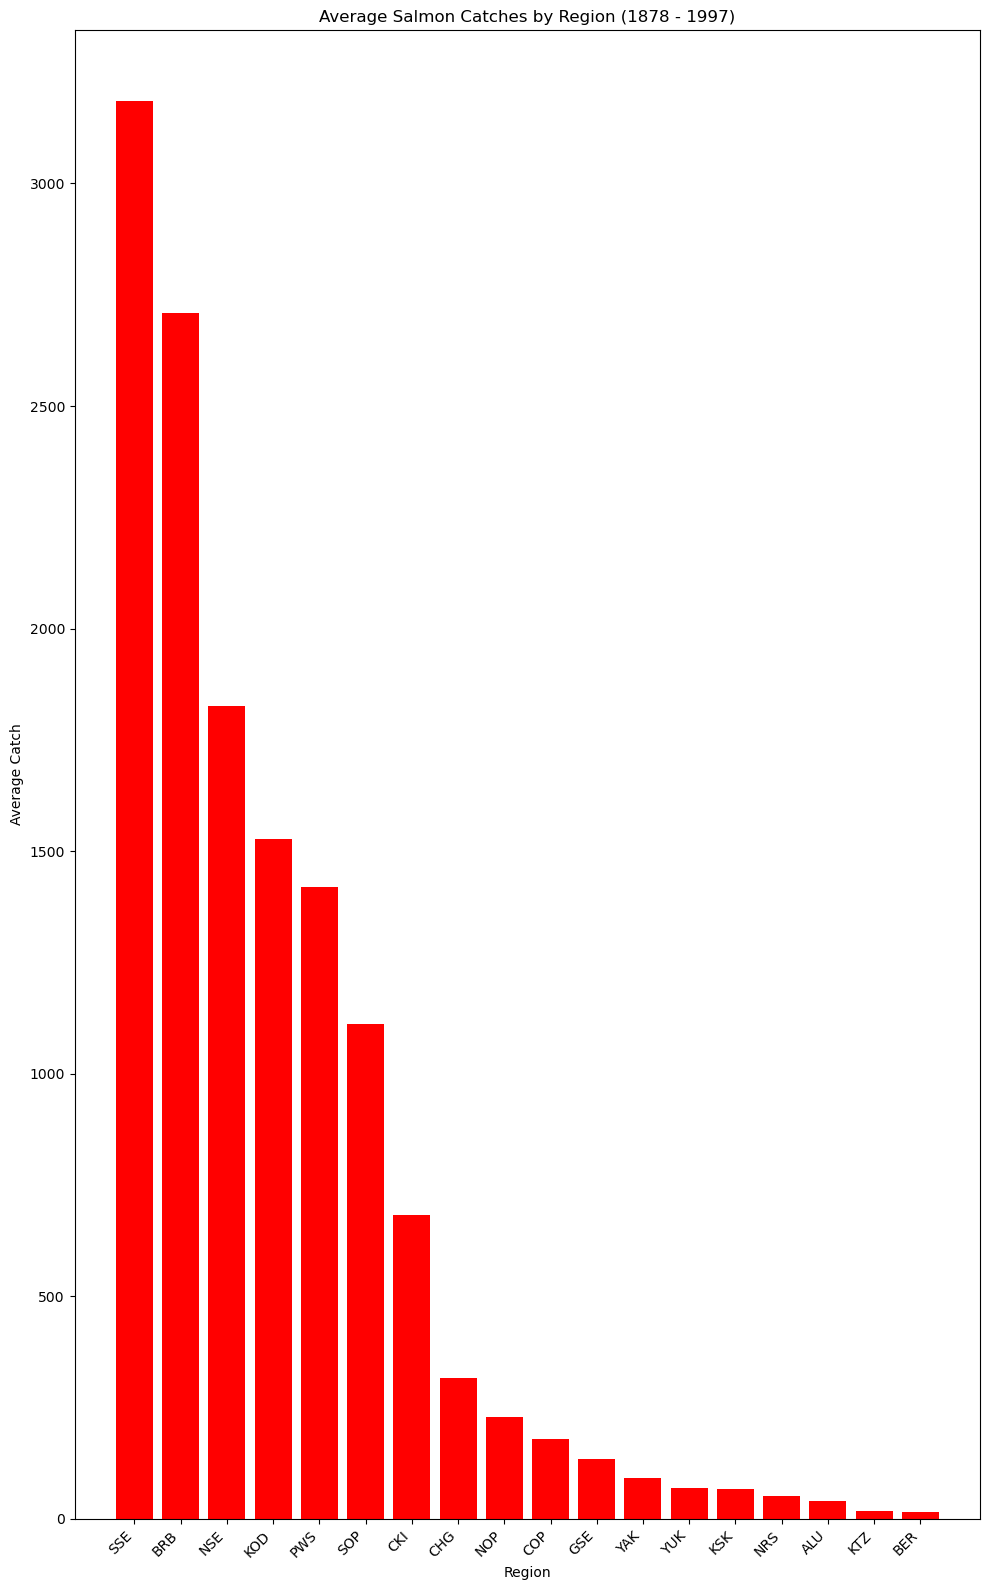

In [61]:
# sorting the data by average catch by descending order
avg_region_sorted = avg_region.sort_values("Catch", ascending=False)

# plotting the sorted data
plt.figure(figsize=(10, 16))
plt.bar(avg_region_sorted["Region"], avg_region_sorted["Catch"], color='red')

# adding labels
plt.title("Average Salmon Catches by Region (1878 - 1997)")
plt.xlabel("Region")
plt.ylabel("Average Catch")
plt.xticks(rotation=45, ha='right')  # needed to rotate text for visability
plt.tight_layout()
plt.show()


<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## 10

Write a brief description with key takeaways from the plot. Your answer shuld use the complete names for the management areas instead of their codes. You can find what each code stands for in the [original data repository](https://knb.ecoinformatics.org/view/df35b.304.2#df35b.303.1).

<!-- END QUESTION -->

## 11

Collect all the relevant code into the first blank cell of the notebook titled "COMPLETE WORKFLOW". This single cell will have the end-to-end workflow: from importing libraries and loading the data, to producing the graph. The *only* ouput of this cell should be the graph you produced in the previous exercise. Further guidance on what to include in this final workflow is in the [assignment rubric](https://docs.google.com/document/d/1x0BoU6IH4cnOR1-n7i9CYQ9wUC37yDpYlQ4j6rCfcsU/edit?tab=t.0).

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [ ]:
grader.check_all()